# Comparative Analysis of Machine Learning Models for Comment Sentiment Classification

**Author:** Aman Sharma  
**Date:** April 2026

## Project Objective

The aim of this project is to train several different models on the comments sentiment data. The data available classifies the comments into three categories: positive, negative, and neutral.

A systematic hyperparameter tuning process will be conducted across various models to identify the most optimal configuration. Upon completion, the best-performing model along with its corresponding hyperparameter set will be selected and retrained on the full dataset.

---

### Methodology Summary

| Phase | Description |
|-------|-------------|
| 1 | Train multiple models on the sentiment-labeled comment data |
| 2 | Experiment with diverse hyperparameter combinations |
| 3 | Evaluate performance to identify optimal settings |
| 4 | Select the best model and hyperparameter configuration |
| 5 | Retrain the final model on the complete dataset |

---

### Data Labels

- **Positive**  
- **Negative**  
- **Neutral**

## Exploratory Data Analysis

In [1]:

import nltk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('https://raw.githubusercontent.com/Himanshu-1703/reddit-sentiment-analysis/refs/heads/main/data/reddit.csv')
df.head()

     

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1


In [2]:

print(df.shape)

print("<newline>")

print(df.sample()['clean_comment'].values)

print("<newline>")

print(df.info())

print("<newline>")


print(df.isnull().sum())


print("<newline>")

print(df[df['clean_comment'].isna()])

print("<newline>")

print(df[df['clean_comment'].isna()]['category'].value_counts())

(37249, 2)
<newline>
['the only participation india will ever have baseball this page cherish while lasts ']
<newline>
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37249 entries, 0 to 37248
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   clean_comment  37149 non-null  object
 1   category       37249 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 582.1+ KB
None
<newline>
clean_comment    100
category           0
dtype: int64
<newline>
      clean_comment  category
413             NaN         0
605             NaN         0
2422            NaN         0
2877            NaN         0
3307            NaN         0
...             ...       ...
35975           NaN         0
36036           NaN         0
37043           NaN         0
37111           NaN         0
37238           NaN         0

[100 rows x 2 columns]
<newline>
category
0    100
Name: count, dtype: int64


In [3]:
df.dropna(inplace=True)

In [4]:
df.duplicated().sum()

np.int64(350)

In [5]:
df[df.duplicated()]

,clean_comment,category
375,,0
392,,0
617,aurum mom,0
651,,0
1222,,0
...,...,...
36915,who won,0
37044,,0
37125,hari,0
37158,top kek,1


In [6]:
df.drop_duplicates(inplace=True)

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df = df[~(df["clean_comment"].str.strip() == "")]

In [9]:
df["clean_comment"] = df["clean_comment"].str.lower()

In [10]:
df["clean_comment"]

0         family mormon have never tried explain them t...
1        buddhism has very much lot compatible with chr...
2        seriously don say thing first all they won get...
3        what you have learned yours and only yours wha...
4        for your own benefit you may want read living ...
                               ...                        
37244                                                jesus
37245    kya bhai pure saal chutiya banaya modi aur jab...
37246                downvote karna tha par upvote hogaya 
37247                                           haha nice 
37248               facebook itself now working bjp’ cell 
Name: clean_comment, Length: 36793, dtype: object

In [11]:
df[df["clean_comment"].apply(lambda x: x.startswith("") or x.endswith(""))]

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1
...,...,...
37244,jesus,0
37245,kya bhai pure saal chutiya banaya modi aur jab...,1
37246,downvote karna tha par upvote hogaya,0
37247,haha nice,1


In [12]:
df["clean_comment"] = df["clean_comment"].str.strip()

In [13]:
urls = r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\(\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+'

df[df["clean_comment"].str.contains(urls,regex=True)]

,clean_comment,category


In [14]:
df[(df["clean_comment"].str.contains("\n"))]

,clean_comment,category
448,what missing jpg\nand why this brilliant edit ...,1
781,india has been ruined congress and populist sc...,-1
847,like aap for its stand corruption and making p...,-1
871,reduced trade\ndeficit stronger rupee aren the...,0
1354,amsa press conference australian maritime safe...,1
...,...,...
35128,火箭o辛基 2016 sughosh bansal mission “make india”...,-1
35230,yikes the title should blind bhakts modi hater...,1
36187,hahahahahhahahah \niska klpd hogya,0
36517,्ा् ी ाी े ो ेी ाी े।\nे ी,0


In [15]:
df["clean_comment"]=df["clean_comment"].str.replace("\n","r")

<Axes: xlabel='category', ylabel='count'>

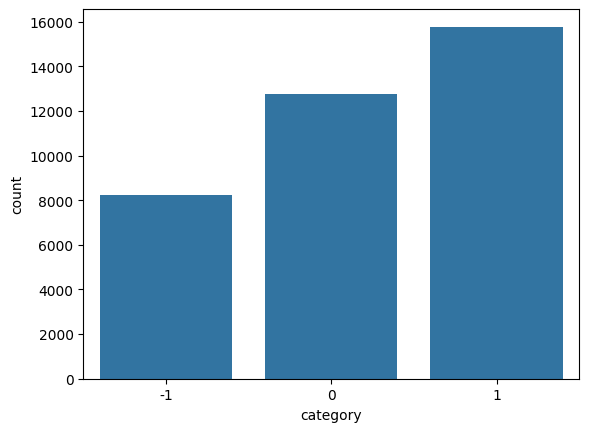

In [16]:
import seaborn as sns

sns.countplot(data=df,x="category")

In [17]:
df["category"].value_counts(normalize=True)*100

category
 1    42.864132
 0    34.713125
-1    22.422743
Name: proportion, dtype: float64

In [18]:
df["wordcount"] = df["clean_comment"].apply(lambda x : len(x.split()))

df

,clean_comment,category,wordcount
0,family mormon have never tried explain them th...,1,39
1,buddhism has very much lot compatible with chr...,1,196
2,seriously don say thing first all they won get...,-1,86
3,what you have learned yours and only yours wha...,0,29
4,for your own benefit you may want read living ...,1,112
...,...,...,...
37244,jesus,0,1
37245,kya bhai pure saal chutiya banaya modi aur jab...,1,19
37246,downvote karna tha par upvote hogaya,0,6
37247,haha nice,1,2


In [19]:
df["wordcount"].describe()

count    36793.000000
mean        29.646645
std         56.648801
min          1.000000
25%          6.000000
50%         13.000000
75%         30.000000
max       1307.000000
Name: wordcount, dtype: float64

(0.0, 200.0)

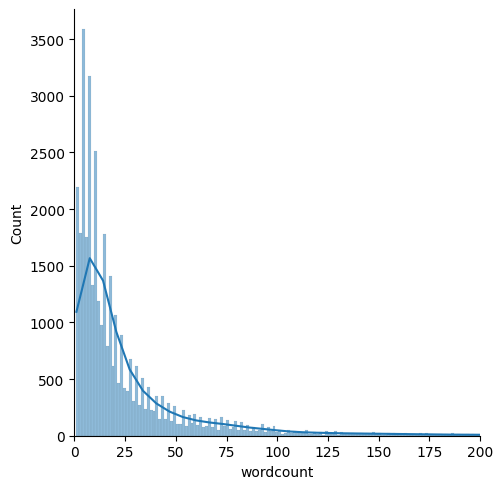

In [20]:
import seaborn as sns 

sns.displot(df["wordcount"],kde=True)

plt.xlim(0,200)

(0.0, 100.0)

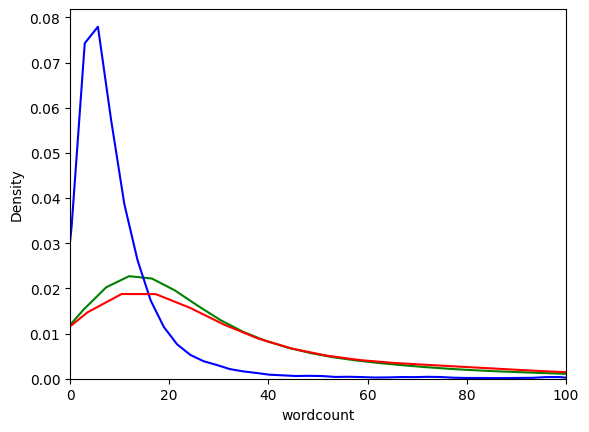

In [21]:
from matplotlib import pyplot as plt



sns.kdeplot(df["wordcount"][df["category"]==-1],color="green")
sns.kdeplot(df["wordcount"][df["category"]==0],color="blue")
sns.kdeplot(df["wordcount"][df["category"]==1],color="red")

plt.xlim(0, 100)

<Axes: ylabel='wordcount'>

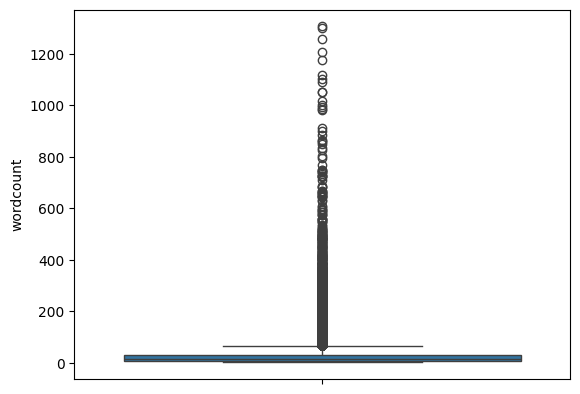

In [22]:
sns.boxplot(df["wordcount"])

<Axes: xlabel='category', ylabel='wordcount'>

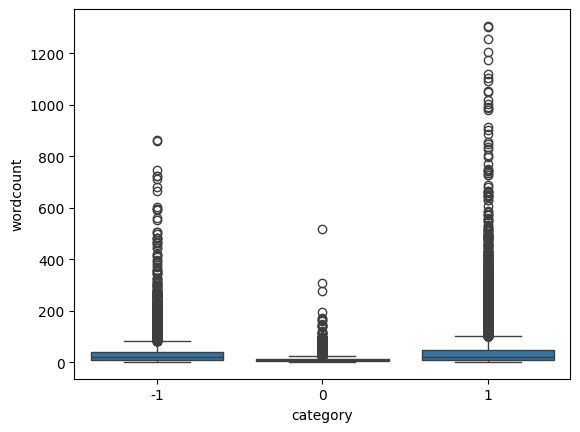

In [23]:
sns.boxplot(data=df, x="category", y="wordcount")

<Axes: xlabel='category', ylabel='wordcount'>

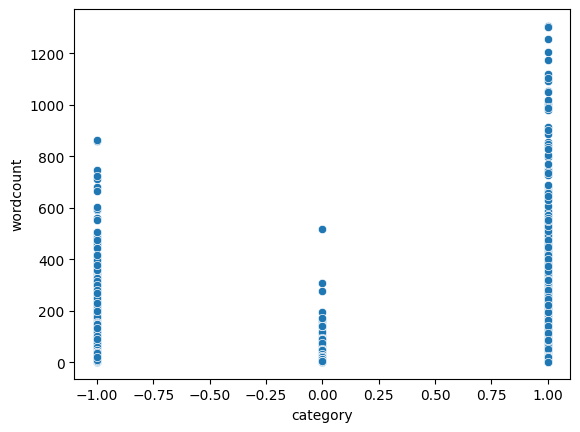

In [24]:
sns.scatterplot(data=df, x="category",y="wordcount")

<Axes: xlabel='category', ylabel='wordcount'>

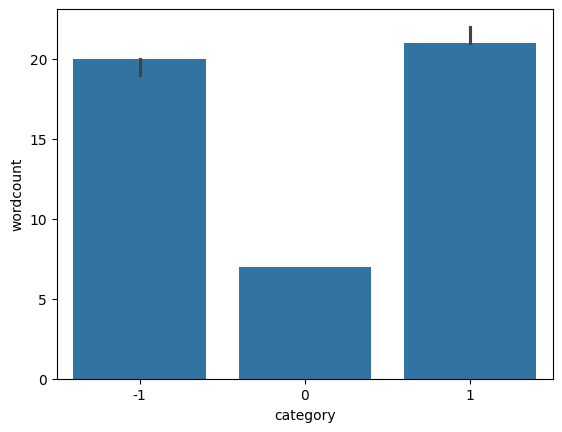

In [25]:
sns.barplot(data=df,x="category",y="wordcount", estimator=np.median)

In [26]:
from nltk.corpus import stopwords

import nltk

nltk.download("stopwords")

stopword=set(stopwords.words("english"))

df["numstopwords"] = df["clean_comment"].apply(lambda x : len([word for word in x.split() if word in stopword]))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


(0.0, 100.0)

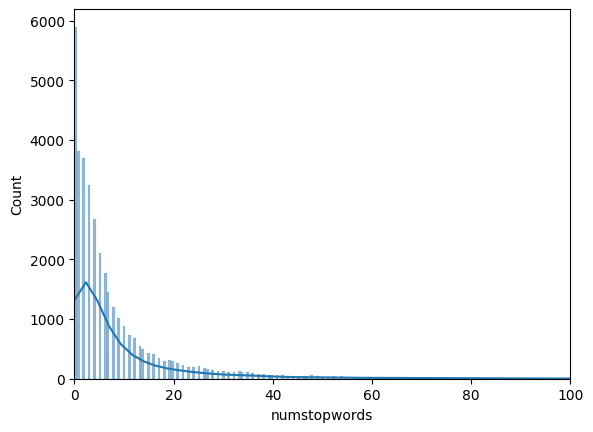

In [27]:
sns.histplot(df["numstopwords"],kde=True)

plt.xlim(0,100)

(0.0, 100.0)

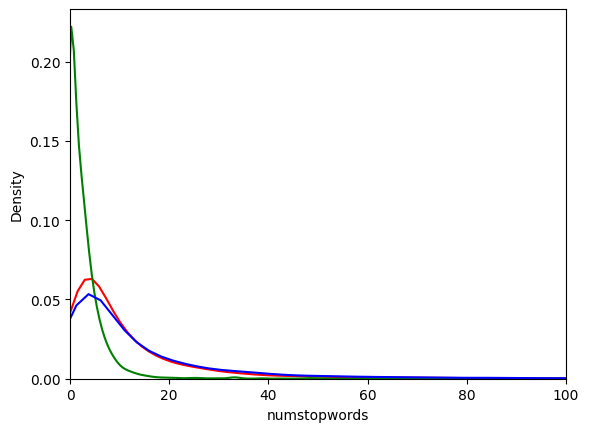

In [28]:
sns.kdeplot(df[df["category"]==-1]["numstopwords"],color="red", label="Category -1")

sns.kdeplot(df[df["category"]==0]["numstopwords"],color="green", label="Category 0")

sns.kdeplot(df[df["category"]==1]["numstopwords"],color="blue", label="Category 1")

plt.xlim(0,100)

In [29]:
df

,clean_comment,category,wordcount,numstopwords
0,family mormon have never tried explain them th...,1,39,13
1,buddhism has very much lot compatible with chr...,1,196,59
2,seriously don say thing first all they won get...,-1,86,40
3,what you have learned yours and only yours wha...,0,29,15
4,for your own benefit you may want read living ...,1,112,45
...,...,...,...,...
37244,jesus,0,1,0
37245,kya bhai pure saal chutiya banaya modi aur jab...,1,19,0
37246,downvote karna tha par upvote hogaya,0,6,0
37247,haha nice,1,2,0


<Axes: xlabel='category', ylabel='numstopwords'>

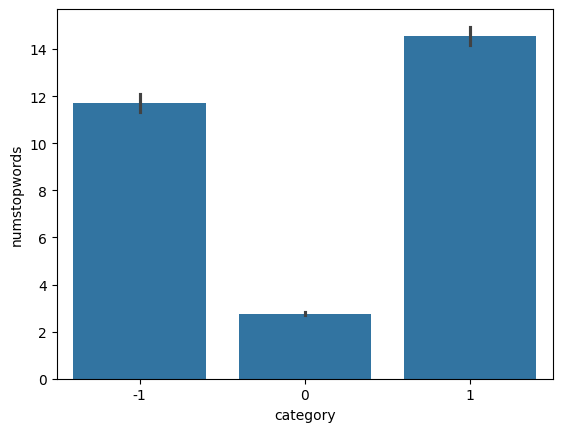

In [30]:
sns.barplot(data=df,x="category",y="numstopwords")

In [31]:
from collections import Counter

allstopwords = [word for comment in df["clean_comment"] for word in comment.split() if word in stopword]

In [32]:
mostcommon=Counter(allstopwords).most_common(25)

In [33]:
mostcommontable = pd.DataFrame(mostcommon,columns=["stopwords","counts"])

<Axes: xlabel='counts', ylabel='stopwords'>

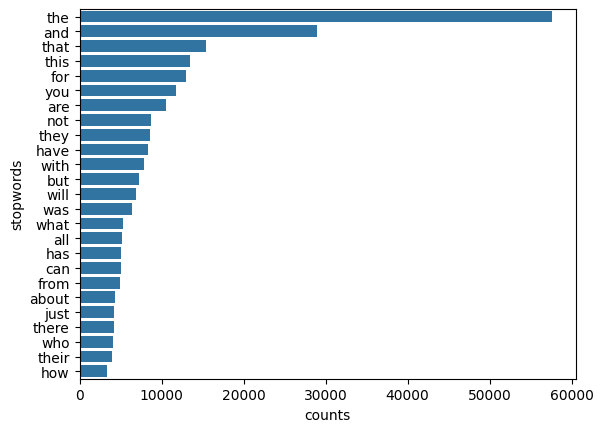

In [34]:
sns.barplot(data=mostcommontable, x="counts", y="stopwords")

In [35]:
df["numchars"]=df["clean_comment"].apply(len)



In [36]:
df["numchars"].describe()

count    36793.000000
mean       181.852798
std        359.702163
min          1.000000
25%         38.000000
50%         80.000000
75%        184.000000
max       8664.000000
Name: numchars, dtype: float64

In [37]:
from collections import Counter

alltexts= " ".join(df["clean_comment"])

charcfreq= Counter(alltexts)

In [38]:
charcfreqtabl= pd.DataFrame(charcfreq.items(),columns=["chars","frequency"])

In [39]:
charcfreqtabl

,chars,frequency
0,f,78866
1,a,481134
2,m,155561
3,i,401388
4,l,250104
...,...,...
1373,ണ,1
1374,р,1
1375,ч,1
1376,т,1


In [40]:
charcfreqtabl["chars"].values

array(['f', 'a', 'm', ..., 'ч', 'т', 'ю'], shape=(1378,), dtype=object)

In [41]:
charcfreqtabl.tail(50)

,chars,frequency
1328,妖,1
1329,婆,1
1330,段,1
1331,她,1
1332,谁,1
1333,抹,1
1334,掉,1
1335,坛,1
1336,回,1
1337,毫,1


In [42]:
df["numofpunctuationchars"] = df["clean_comment"].apply(lambda x : sum([1 for char in x if char in '.,!?;:"\'()[]{}-']))

In [43]:
df["numofpunctuationchars"].describe()

count    36793.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: numofpunctuationchars, dtype: float64

In [44]:
from sklearn.feature_extraction.text import CountVectorizer
vec = CountVectorizer(ngram_range=(2,2),stop_words="english").fit(df["clean_comment"])

bagofwods=vec.transform(df["clean_comment"])

sumss=bagofwods.sum(axis=0)


In [45]:
wodsfreq= [(word,sumss[0,idx]) for word,idx in vec.vocabulary_.items()]

wodsfreq=sorted(wodsfreq, key = lambda x : x[1], reverse = True)

<Axes: xlabel='numbs', ylabel='vocs'>

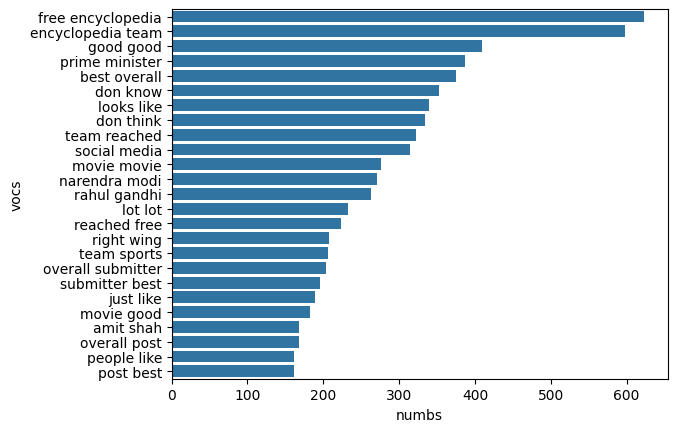

In [46]:
wodsfreq[:25]

bagsfreq=pd.DataFrame(wodsfreq,columns=["vocs","numbs"])

import seaborn as sns

sns.barplot(data = bagsfreq[:25], x="numbs" , y = "vocs")

<Axes: xlabel='numbs', ylabel='vocs'>

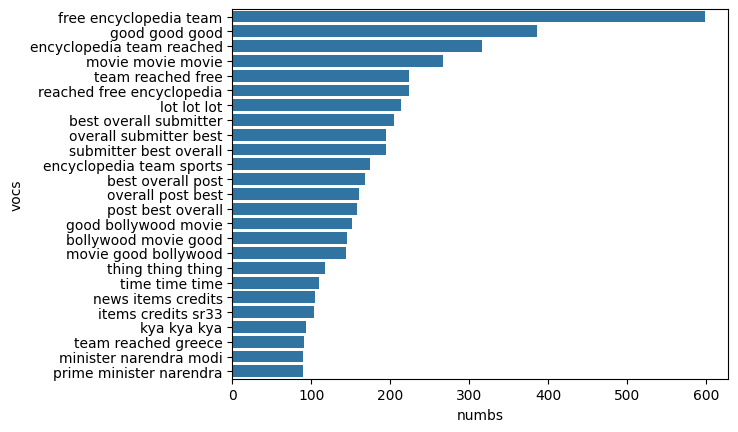

In [47]:
from sklearn.feature_extraction.text import CountVectorizer

vec = CountVectorizer(ngram_range=(3,3),stop_words="english").fit(df["clean_comment"])

bagofwods=vec.transform(df["clean_comment"])

sumss=bagofwods.sum(axis=0)


wodsfreq= [(word,sumss[0,idx]) for word,idx in vec.vocabulary_.items()]

wodsfreq=sorted(wodsfreq, key = lambda x : x[1], reverse = True)


wodsfreq[:25]

bagsfreq=pd.DataFrame(wodsfreq,columns=["vocs","numbs"])

import seaborn as sns

sns.barplot(data = bagsfreq[:25], x="numbs" , y = "vocs")

In [48]:
import re
df["clean_comment"] = df["clean_comment"].apply(lambda x: re.sub(r"[^A-Za-z0-9\s!?.,]","",str(x)))

In [49]:
alltext= "".join(df["clean_comment"])

In [50]:
aaa=Counter(alltext)

charsfre=pd.DataFrame(aaa.items(),columns=["chars","wordfreq"]).sort_values(by="wordfreq",ascending =False)

In [51]:
charsfre.head()

,chars,wordfreq
6,,1054029
12,e,666610
13,t,491287
1,a,481134
3,i,401388


In [52]:
from nltk.corpus import stopwords

wods = set(stopwords.words("english")) - {'not', 'but', 'however', 'no', 'yet'}

df["clean_comment"] = df["clean_comment"].apply(lambda x : " ".join([word for word in x.split() if word not in wods]))

In [53]:

from nltk.stem import WordNetLemmatizer

nltk.download("wordnet")

dd= WordNetLemmatizer()

df["clean_comment"] = df["clean_comment"].apply(lambda x : " ".join([dd.lemmatize(word) for word in x.split()]))



[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [54]:
!pip install wordcloud

In [55]:
from wordcloud import WordCloud

text2 = df["clean_comment"]

text1 = df[df["category"] == 1]["clean_comment"]

wodcd = WordCloud().generate(" ".join(text1))

wodcd2 = WordCloud().generate(" ".join(text2))

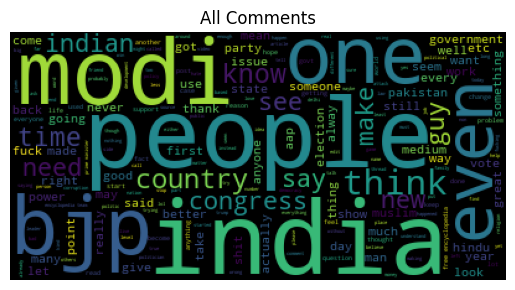

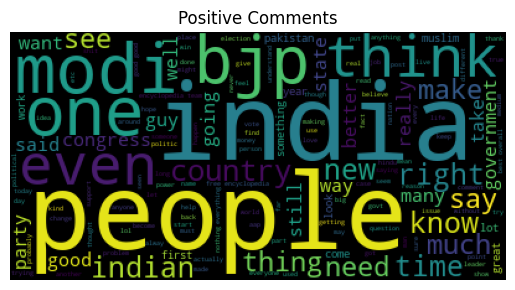

In [56]:
plt.title("All Comments")
plt.imshow(wodcd2)
plt.axis("off")
plt.show()

plt.title("Positive Comments")
plt.imshow(wodcd)
plt.axis("off")
plt.show()

In [57]:
words = " ".join(df["clean_comment"]).split()

cont=Counter(words)
dd=cont.most_common(25)

words,counts=zip(*dd)


<Axes: >

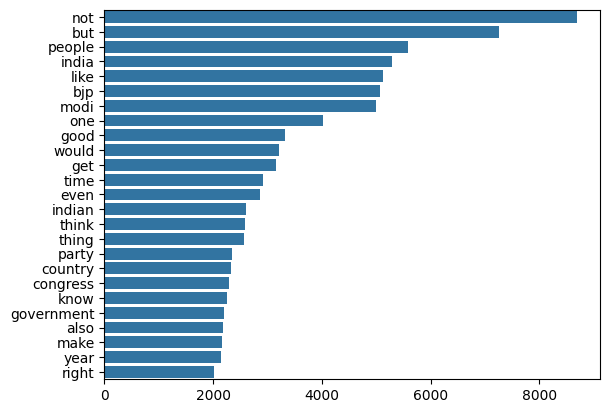

In [58]:
import seaborn as sns

sns.barplot(x=list(counts),y=list(words))

In [59]:
df

,clean_comment,category,wordcount,numstopwords,numchars,numofpunctuationchars
0,family mormon never tried explain still stare ...,1,39,13,259,0
1,buddhism much lot compatible christianity espe...,1,196,59,1268,0
2,seriously say thing first get complex explain ...,-1,86,40,459,0
3,learned want teach different focus goal not wr...,0,29,15,167,0
4,benefit may want read living buddha living chr...,1,112,45,690,0
...,...,...,...,...,...,...
37244,jesus,0,1,0,5,0
37245,kya bhai pure saal chutiya banaya modi aur jab...,1,19,0,99,0
37246,downvote karna tha par upvote hogaya,0,6,0,36,0
37247,haha nice,1,2,0,9,0


## Data Processing and Model Training

In [60]:
#import mlflow
#import mlflow.sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_predict,StratifiedKFold
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns




In [61]:
vectorizer=CountVectorizer(max_features=10000)

In [62]:
X=vectorizer.fit_transform(df["clean_comment"]).toarray()

In [63]:
y=df["category"]

In [64]:
y

0        1
1        1
2       -1
3        0
4        1
        ..
37244    0
37245    1
37246    0
37247    1
37248    0
Name: category, Length: 36793, dtype: int64

In [65]:
trainx,testx,trainy,testy = train_test_split(X,y,test_size=0.2,random_state=42)

In [66]:
#!pip install boto3

In [67]:
#!pip install awscli

In [68]:
#import mlflow

In [69]:
vectorizer

,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (strip_accents and lowercase) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None
,"stop_words stop_words: {'english'}, list, default=NoneIf 'english', a built-in stop word list for English is used.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",None
,"token_pattern token_pattern: str or None, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp select tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.",'(?u)\\b\\w\\w+\\b'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentword n-grams or char n-grams to be extracted. All values of n suchsuch that min_n <= n <= max_n will be used. For example an``ngram_range`` of ``(1, 1)`` means only unigrams, ``(1, 2)`` meansunigrams and bigrams, and ``(2, 2)`` means only bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word n-gram or charactern-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21Since v0.21, if ``input`` is ``filename`` or ``file``, the data isfirst read from the file and then passed to the given callableanalyzer.",'word'


C:\Users\lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


-1_precision 0.0
-1_recall 0.0
-1_f1-score 0.0
-1_support 1671.0
0_precision 0.7145207733443028
0_recall 0.6714340935446463
0_f1-score 0.6923076923076923
0_support 2587.0
1_precision 0.565137987012987
1_recall 0.8980973879393744
1_f1-score 0.6937352098642421
1_support 3101.0
macro avg_precision 0.42655292011909657
macro avg_recall 0.5231771604946736
macro avg_f1-score 0.4620143007239781
macro avg_support 7359.0
weighted avg_precision 0.4893271012867215
weighted avg_recall 0.6144856638130181
weighted avg_f1-score 0.535707689331297
weighted avg_support 7359.0
Accuracy: 0.6144856638130181


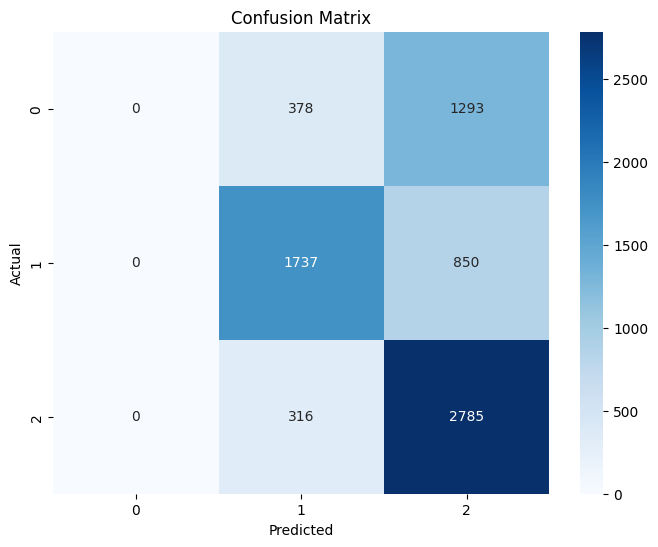

In [155]:


# Log Random Forest parameters
n_estimators = 100
max_depth = 10



# Initialize and train the model
model = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=42)
model.fit(trainx, trainy)

# Make predictions on the test set
y_pred = model.predict(testx)

# Log metrics for each class and accuracy
accuracy = accuracy_score(testy, y_pred)


classification_rep = classification_report(testy, y_pred, output_dict=True)

for label, metrics in classification_rep.items():
    if isinstance(metrics, dict):  # For precision, recall, f1-score, etc.
        for metric, value in metrics.items():
            print(f"{label}_{metric}", value)

# Confusion matrix plot
conf_matrix = confusion_matrix(testy, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")



# Display final accuracy
print(f"Accuracy: {accuracy}")

In [156]:
#mlflow.set_tracking_uri("http://3.216.132.134:5000")
#mlflow.set_experiment("RF3 Baseline")


ngramrange (1, 1)
-1_precision 1.0
-1_recall 0.0011968880909634949
-1_f1-score 0.002390914524805738
-1_support 1671.0
0_precision 0.6847290640394089
0_recall 0.7522226517201391
0_f1-score 0.7168907717811752
0_support 2587.0
1_precision 0.5991140642303433
1_recall 0.872299258303773
1_f1-score 0.7103466386554622
1_support 3101.0
macro avg_precision 0.761281042756584
macro avg_recall 0.5419062660382918
macro avg_f1-score 0.47654277498714775
macro avg_support 7359.0
weighted avg_precision 0.7202400872194926
weighted avg_recall 0.6322869955156951
weighted avg_f1-score 0.5518924543062154
weighted avg_support 7359.0
Accuracy: 0.6322869955156951
ngramrange (1, 2)
-1_precision 1.0
-1_recall 0.0017953321364452424
-1_f1-score 0.0035842293906810036
-1_support 1671.0
0_precision 0.6911225238444607
0_recall 0.7282566679551604
0_f1-score 0.7092038396386222
0_support 2587.0
1_precision 0.5894168466522678
1_recall 0.8800386971944534
1_f1-score 0.7059888759539517
1_support 3101.0
macro avg_precision 0.7

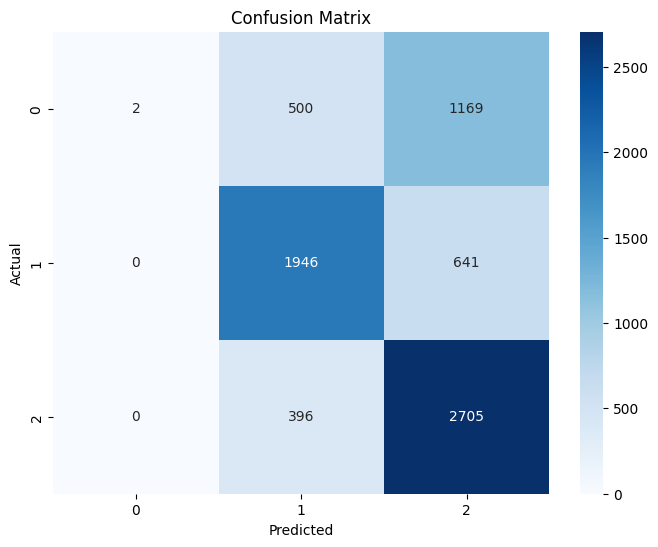

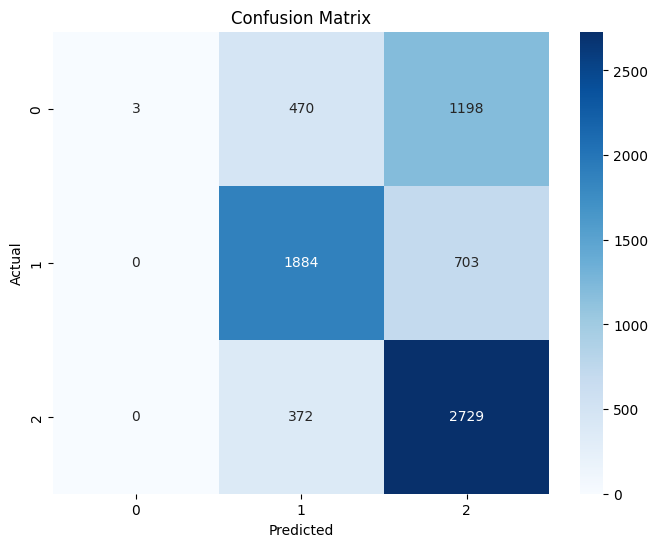

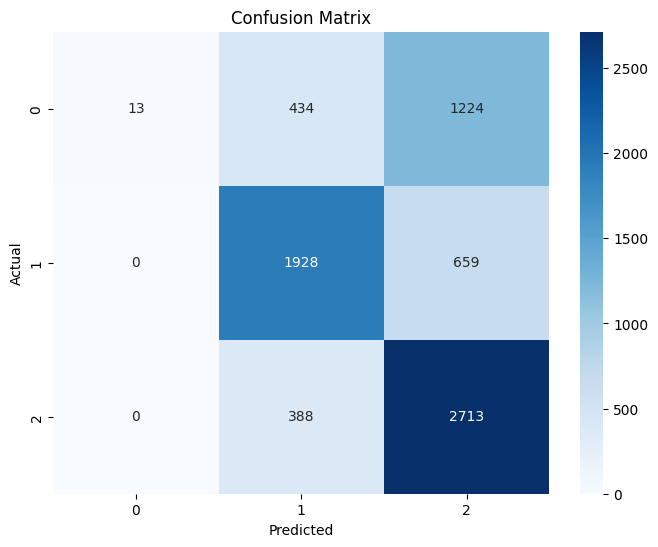

In [157]:
def exp(ngrams):

    vectorizer=TfidfVectorizer(ngram_range=ngrams,max_features=5000)
    
    trainx,testx,trainy,testy=train_test_split(df["clean_comment"],df["category"],test_size=0.2,random_state=42)
    trainx=vectorizer.fit_transform(trainx)
    testx=vectorizer.transform(testx)

   

    print("ngramrange",ngrams)
    # Log Random Forest parameters
    n_estimators = 100
    max_depth = 10

    # Initialize and train the model
    model = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=42)
    model.fit(trainx, trainy)

    # Make predictions on the test set
    y_pred = model.predict(testx)

    # Log metrics for each class and accuracy
    accuracy = accuracy_score(testy, y_pred)
    

    classification_rep = classification_report(testy, y_pred, output_dict=True)

    for label, metrics in classification_rep.items():
        if isinstance(metrics, dict):  # For precision, recall, f1-score, etc.
            for metric, value in metrics.items():
                print(f"{label}_{metric}", value)

    # Confusion matrix plot
    conf_matrix = confusion_matrix(testy, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")


      
    # Display final accuracy
    print(f"Accuracy: {accuracy}")

for ngrams in [(1,1),(1,2),(1,3)]:

    exp(ngrams)
    


ngramrange (1, 3)
features 1000
-1_precision 0.9387755102040817
-1_recall 0.02752842609216038
-1_f1-score 0.053488372093023255
-1_support 1671.0
0_precision 0.6128472222222222
0_recall 0.818708929261693
0_f1-score 0.7009763362568261
0_support 2587.0
1_precision 0.6299948105864037
1_recall 0.782973234440503
1_f1-score 0.6982027318475916
1_support 3101.0
macro avg_precision 0.7272058476709026
macro avg_recall 0.5430701965981188
macro avg_f1-score 0.4842224800658137
macro avg_support 7359.0
weighted avg_precision 0.6940811997646892
weighted avg_recall 0.6239978257915477
weighted avg_f1-score 0.5527831937930742
weighted avg_support 7359.0
Accuracy: 0.6239978257915477
ngramrange (1, 3)
features 2000
-1_precision 1.0
-1_recall 0.023937761819269897
-1_f1-score 0.046756282875511396
-1_support 1671.0
0_precision 0.6460459183673469
0_recall 0.7831465017394665
0_f1-score 0.7080202690896383
0_support 2587.0
1_precision 0.6129572077456371
1_recall 0.8268300548210255
1_f1-score 0.7040087863811093
1_

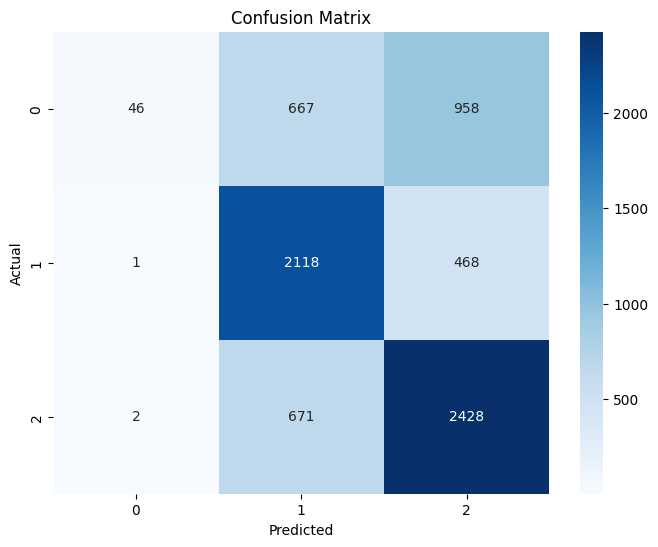

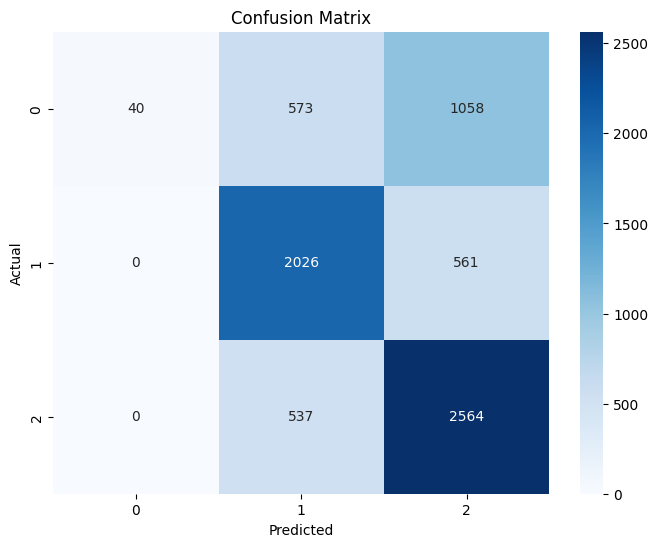

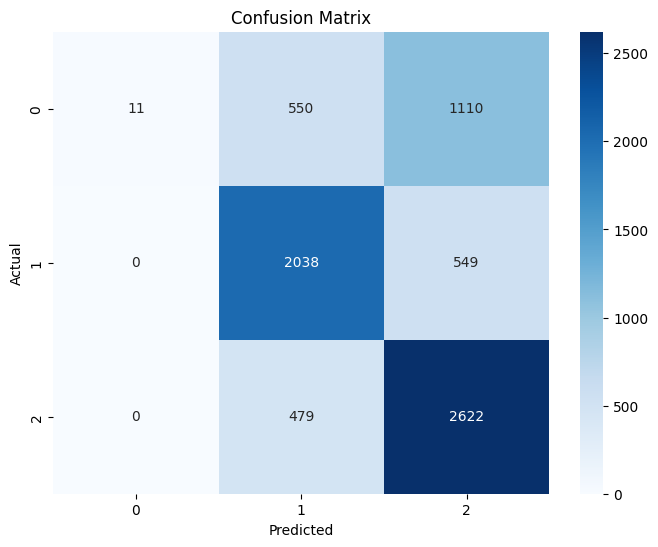

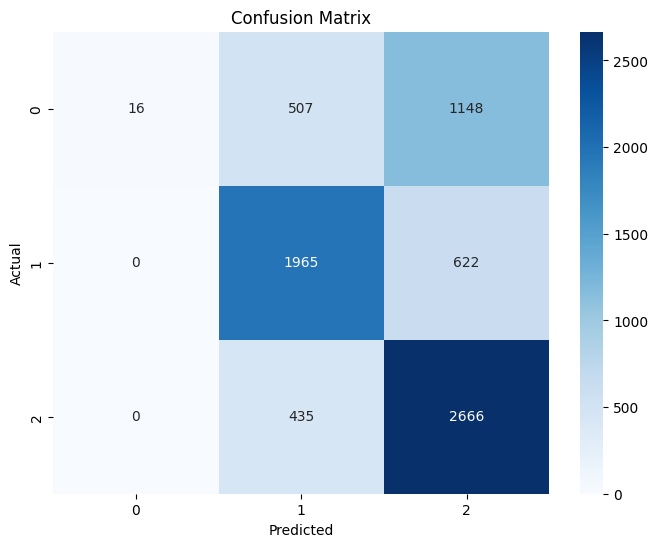

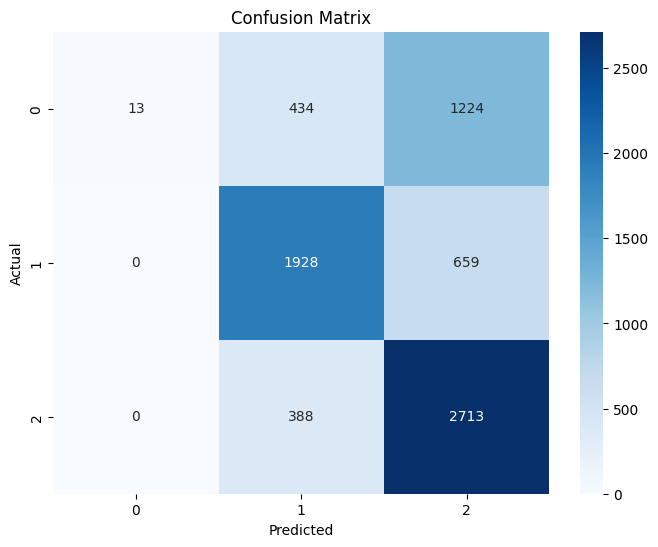

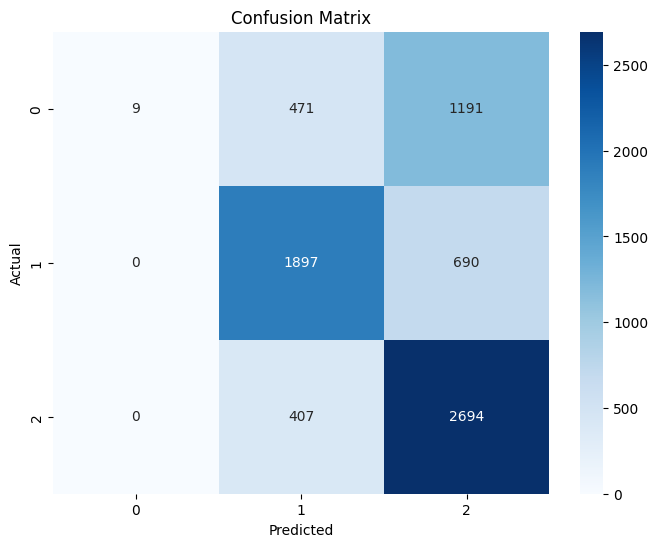

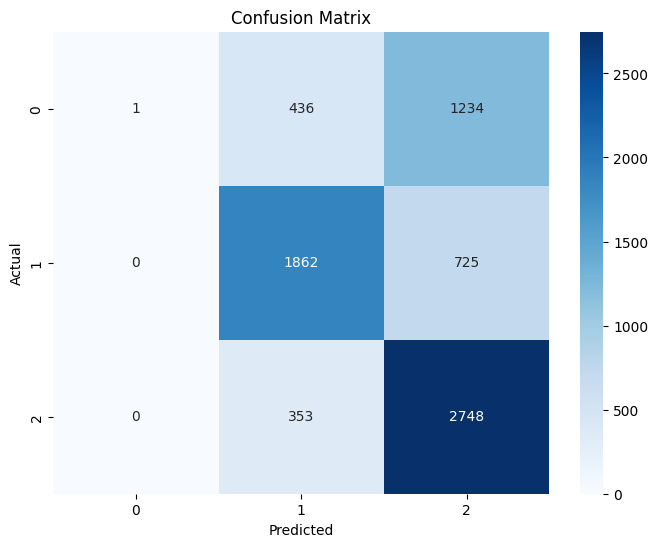

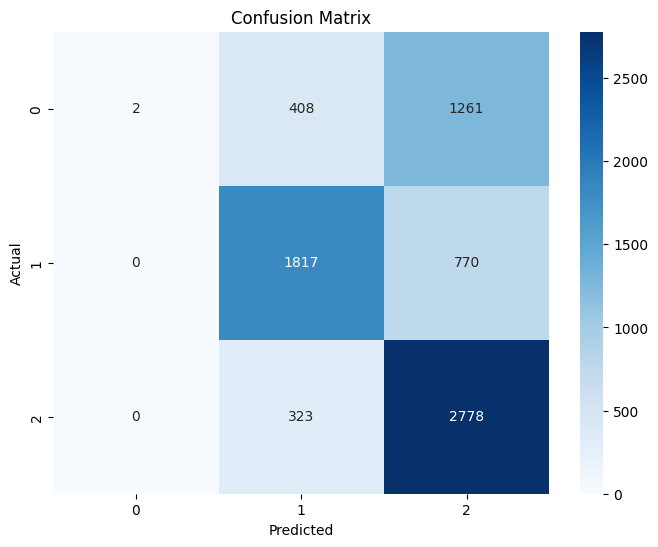

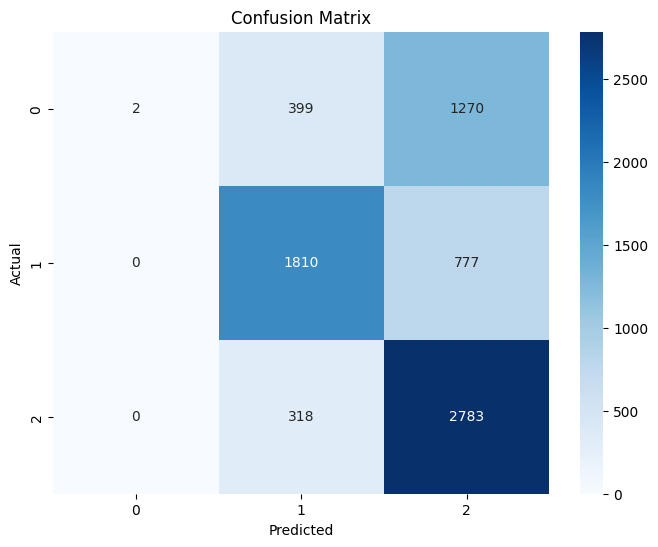

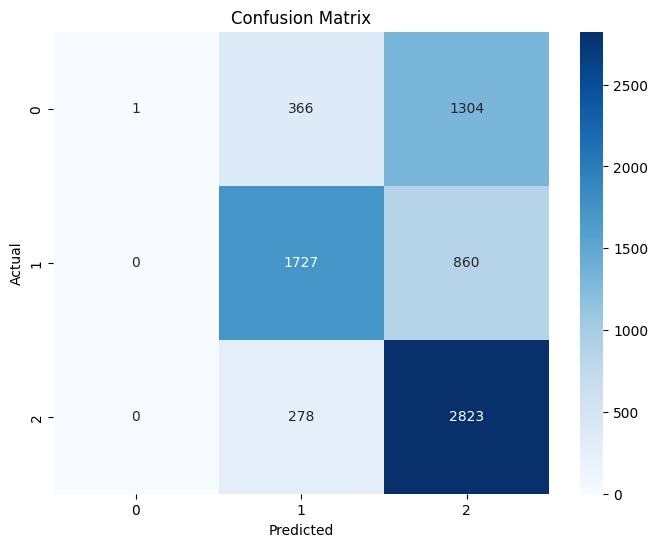

In [158]:
def exp(feats):
    ngrams=(1,3)
    vectorizer=TfidfVectorizer(ngram_range=ngrams,max_features=feats)
    
    trainx,testx,trainy,testy=train_test_split(df["clean_comment"],df["category"],test_size=0.2,random_state=42)
    trainx=vectorizer.fit_transform(trainx)
    testx=vectorizer.transform(testx)


    print("ngramrange",ngrams)
    print("features",feats)
    # Log Random Forest parameters
    n_estimators = 100
    max_depth = 10



    # Initialize and train the model
    model = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=42)
    model.fit(trainx, trainy)

    # Make predictions on the test set
    y_pred = model.predict(testx)

    # Log metrics for each class and accuracy
    accuracy = accuracy_score(testy, y_pred)
  

    classification_rep = classification_report(testy, y_pred, output_dict=True)

    for label, metrics in classification_rep.items():
        if isinstance(metrics, dict):  # For precision, recall, f1-score, etc.
            for metric, value in metrics.items():
                print(f"{label}_{metric}", value)

    # Confusion matrix plot
    conf_matrix = confusion_matrix(testy, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")


    # Display final accuracy
    print(f"Accuracy: {accuracy}")

for feats in [1000,2000,3000,4000,5000,6000,7000,8000,9000,10000]:

    exp(feats)

In [159]:
#mlflow.set_tracking_uri("http://3.234.254.16:5000")
#mlflow.set_experiment("RF3 Baseline")


In [72]:
#!pip install --upgrade imbalanced-learn
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTEENN
from imblearn.under_sampling import RandomUnderSampler

method oversampling
-1_precision 0.6100872938894277
-1_recall 0.37642130460801915
-1_f1-score 0.4655810510732791
-1_support 1671.0
0_precision 0.5714966634890372
0_recall 0.926942404329339
0_f1-score 0.707061772077252
0_support 2587.0
1_precision 0.8048780487804879
1_recall 0.5533698806836505
1_f1-score 0.6558379514618765
1_support 3101.0
macro avg_precision 0.6621540020529842
macro avg_recall 0.6189111965403362
macro avg_f1-score 0.6094935915374692
macro avg_support 7359.0
weighted avg_precision 0.6786036915074963
weighted avg_recall 0.6445169180595189
weighted avg_f1-score 0.6306438684862861
weighted avg_support 7359.0
Accuracy: 0.6445169180595189
method adasyn
-1_precision 0.6547770700636942
-1_recall 0.3076002393776182
-1_f1-score 0.4185667752442997
-1_support 1671.0
0_precision 0.5116755428103237
0_recall 0.9655972168534983
0_f1-score 0.6688981121970813
0_support 2587.0
1_precision 0.816193853427896
1_recall 0.4453402128345695
1_f1-score 0.5762570415188817
1_support 3101.0
macro a

C:\Users\lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


-1_precision 0.22737787454075384
-1_recall 1.0
-1_f1-score 0.370509977827051
-1_support 1671.0
0_precision 0.0
0_recall 0.0
0_f1-score 0.0
0_support 2587.0
1_precision 1.0
1_recall 0.0032247662044501773
1_f1-score 0.006428801028608165
1_support 3101.0
macro avg_precision 0.40912595818025127
macro avg_recall 0.3344082554014834
macro avg_f1-score 0.12564625961855305
macro avg_support 7359.0
weighted avg_precision 0.473019218420655
weighted avg_recall 0.2284277755129773
weighted avg_f1-score 0.08684031593133797
weighted avg_support 7359.0
Accuracy: 0.2284277755129773


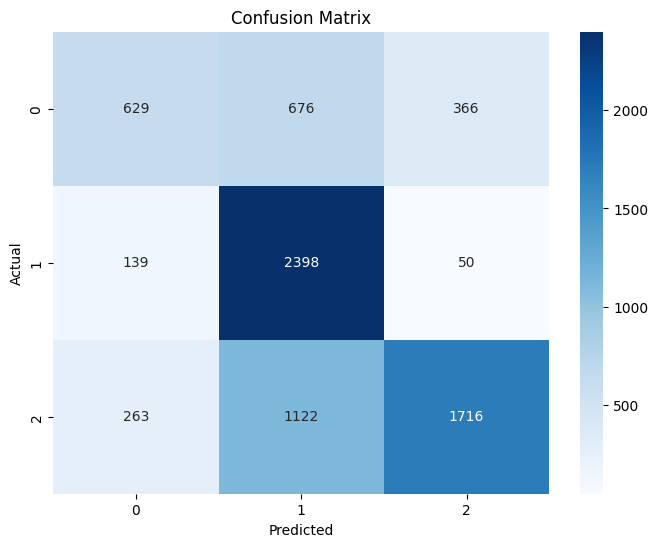

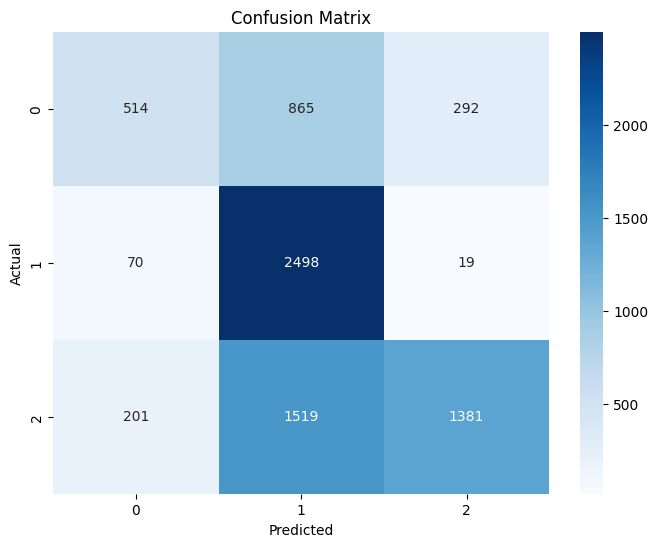

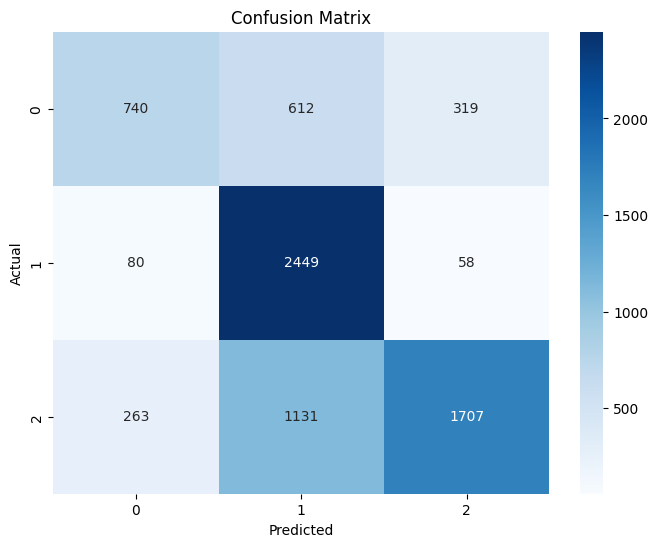

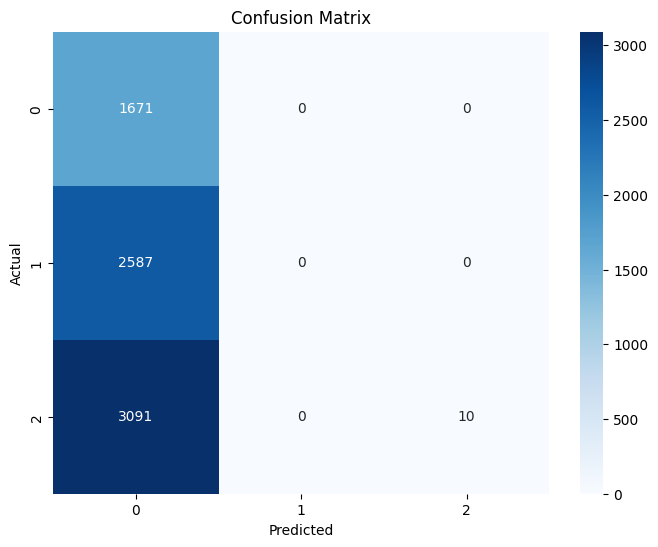

In [161]:
def exp(methods):
    ngrams=(1,3)
    feats = 10000
    vectorizer=TfidfVectorizer(ngram_range=ngrams,max_features=feats)
    
    trainx,testx,trainy,testy=train_test_split(df["clean_comment"],df["category"],test_size=0.2,random_state=42)
    trainx=vectorizer.fit_transform(trainx)
    testx=vectorizer.transform(testx)



    if methods=="oversampling":
        smote=SMOTE(random_state=42)
        trainx,trainy = smote.fit_resample(trainx,trainy)
    elif methods== "adasyn":   
        adasyn=ADASYN(random_state=42)
        trainx,trainy = adasyn.fit_resample(trainx,trainy)
    elif methods ==  "undersamplerresampling":
        rus = RandomUnderSampler(random_state = 42)
        trainx,trainy = rus.fit_resample(trainx,trainy)
    elif methods == "smotenn":
        smotenn= SMOTEENN(random_state = 42)
        trainx,trainy = smotenn.fit_resample(trainx,trainy)
        


    print("method",methods)
    # Log Random Forest parameters
    n_estimators = 100
    max_depth = 10

    


    # Initialize and train the model
    model = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=42)
    model.fit(trainx, trainy)

    # Make predictions on the test set
    y_pred = model.predict(testx)

    # Log metrics for each class and accuracy
    accuracy = accuracy_score(testy, y_pred)
    

    classification_rep = classification_report(testy, y_pred, output_dict=True)

    for label, metrics in classification_rep.items():
        if isinstance(metrics, dict):  # For precision, recall, f1-score, etc.
            for metric, value in metrics.items():
                print(f"{label}_{metric}", value)

    # Confusion matrix plot
    conf_matrix = confusion_matrix(testy, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")





    # Display final accuracy
    print(f"Accuracy: {accuracy}")

for methods in ["oversampling" , "adasyn" , "undersamplerresampling", "smotenn"]:

    exp(methods)

In [162]:
#!pip install optuna xgboost 

In [71]:


import optuna
from xgboost import XGBClassifier
df.head()

,clean_comment,category,wordcount,numstopwords,numchars,numofpunctuationchars
0,family mormon never tried explain still stare ...,1,39,13,259,0
1,buddhism much lot compatible christianity espe...,1,196,59,1268,0
2,seriously say thing first get complex explain ...,-1,86,40,459,0
3,learned want teach different focus goal not wr...,0,29,15,167,0
4,benefit may want read living buddha living chr...,1,112,45,690,0


In [73]:
ngrams=(1,3)
feats = 10000
vectorizer=TfidfVectorizer(ngram_range=ngrams,max_features=feats)

trainx,testx,trainy,testy=train_test_split(df["clean_comment"],df['category'],test_size=0.2,random_state=42)
trainx=vectorizer.fit_transform(trainx)
testx=vectorizer.transform(testx)

trainy = trainy.map({-1: 2, 0: 0, 1: 1})
testy = testy.map({-1: 2, 0: 0, 1: 1})

smote=SMOTE(random_state=42)



trainx,trainy = smote.fit_resample(trainx,trainy)


def objxgboost(trial):
    nestims=trial.suggest_int("n_estimators",50,300)
    lrt  = trial.suggest_float("learning_rate", 1e-4, 1e-1 , log=True)
    maxdep = trial.suggest_int("max_depth", 3, 10)
    model = XGBClassifier(n_estimators=nestims,learning_rate=lrt,max_depth=maxdep, random_state =42 )
    model.fit(trainx,trainy)
    return(accuracy_score(testy,model.predict(testx)))

def exp():


    study = optuna.create_study(direction="maximize")
    study.optimize(objxgboost,n_trials=30)
    bestparams= study.best_params
    bmodel=XGBClassifier(n_estimators=bestparams["n_estimators"], learning_rates=bestparams["learning_rate"], max_depths=bestparams["max_depth"],random_state=42)
        
    print("n_estimators",bestparams["n_estimators"])
    print("max_depth", bestparams["max_depth"])
    print("learning_rate", bestparams["learning_rate"])

    # Initialize and train the model
    #model = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=42)
    bmodel.fit(trainx, trainy)

    # Make predictions on the test set
    y_pred = bmodel.predict(testx)

    # Log metrics for each class and accuracy
    accuracy = accuracy_score(testy, y_pred)


    classification_rep = classification_report(testy, y_pred, output_dict=True)

    for label, metrics in classification_rep.items():
        if isinstance(metrics, dict):  # For precision, recall, f1-score, etc.
            for metric, value in metrics.items():
                print(f"{label}_{metric}", value)

    # Confusion matrix plot
    conf_matrix = confusion_matrix(testy, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")

    # Display final accuracy
    print(f"Accuracy: {accuracy}")

exp()

[I 2026-04-08 13:14:44,726] A new study created in memory with name: no-name-d866a09e-adaf-4e69-8098-742fbc41977a
[I 2026-04-08 13:16:20,946] Trial 0 finished with value: 0.6114961271911945 and parameters: {'n_estimators': 52, 'learning_rate': 0.007259166381445872, 'max_depth': 9}. Best is trial 0 with value: 0.6114961271911945.
[I 2026-04-08 13:20:47,931] Trial 1 finished with value: 0.6133985595869004 and parameters: {'n_estimators': 117, 'learning_rate': 0.00030557013889160255, 'max_depth': 10}. Best is trial 1 with value: 0.6133985595869004.
[I 2026-04-08 13:28:41,825] Trial 2 finished with value: 0.600896860986547 and parameters: {'n_estimators': 253, 'learning_rate': 0.0011019166288705406, 'max_depth': 9}. Best is trial 1 with value: 0.6133985595869004.
[I 2026-04-08 13:30:30,506] Trial 3 finished with value: 0.5750781356162522 and parameters: {'n_estimators': 120, 'learning_rate': 0.003009351751227786, 'max_depth': 6}. Best is trial 1 with value: 0.6133985595869004.
[I 2026-04-0

KeyboardInterrupt: 

In [ ]:
#!pip install lightgbm
from lightgbm import LGBMClassifier

In [ ]:
ngrams=(1,3)
feats = 10000
vectorizer=TfidfVectorizer(ngram_range=ngrams,max_features=feats)

trainx,testx,trainy,testy=train_test_split(df["clean_comment"],df['category'],test_size=0.2,random_state=42)
trainx=vectorizer.fit_transform(trainx)
testx=vectorizer.transform(testx)

trainy = trainy.map({-1: 2, 0: 0, 1: 1})
testy = testy.map({-1: 2, 0: 0, 1: 1})

smote=SMOTE(random_state=42)



trainx,trainy = smote.fit_resample(trainx,trainy)

def lightgbmboost(trial):
    nestims=trial.suggest_int("n_estimators",100,1000)
    lrt  = trial.suggest_float("learning_rate", 1e-4, 1e-1 , log=True)
    maxdep = trial.suggest_int("max_depth", 3, 15)
    numleaves=trial.suggest_int("numleaves",20,150)
    minchildsamples=trial.suggest_int("minchildsamples",10,100)
    colsamplebytree=trial.suggest_float("colsamplebytree",0.5,1.0)
    subsample=trial.suggest_float("subsample",0.5,1.0)
    regalpha=trial.suggest_float("regalpha",1e-4,10,log=True)
    reglambda=trial.suggest_float("reglambda",1e-4,10,log=True)
    model = LGBMClassifier(n_estimators=nestims, 
                        learning_rate=lrt, 
                        max_depth=maxdep,
                        num_leaves=numleaves,
                        min_child_samples=minchildsamples,
                        colsample_bytree=colsamplebytree,
                        subsample=subsample,
                        reg_alpha=regalpha,
                        reg_lambda=reglambda,
                        random_state=42,
                          verbose=-1 )
    model.fit(trainx,trainy)
    return(accuracy_score(testy,model.predict(testx)))

def exp():


    study = optuna.create_study(direction="maximize")
    study.optimize(lightgbmboost,n_trials=100)
    bestparams= study.best_params
    bmodel=LGBMClassifier(n_estimators=bestparams["n_estimators"], 
                        learning_rate=bestparams["learning_rate"], 
                        max_depth=bestparams["max_depth"],
                        num_leaves=bestparams["numleaves"],
                        min_child_samples=bestparams["minchildsamples"],
                        colsample_bytree=bestparams["colsamplebytree"],
                        subsample=bestparams["subsample"],
                        reg_alpha=bestparams["regalpha"],
                        reg_lambda=bestparams["reglambda"],
                        random_state=42,
                         verbose=-1 )
    
        

    
        
        # Log Random Forest parameters
    
        
    print("n_estimators",bestparams["n_estimators"])
    print("max_depth", bestparams["max_depth"])
    print("learning_rate",bestparams["learning_rate"]) 
    print("numleaves",bestparams["numleaves"])
    print("minchildsamples",bestparams["minchildsamples"])
    print("colsamplebytree",bestparams["colsamplebytree"])
    print("subsample",bestparams["subsample"])
    print("regalpha",bestparams["regalpha"])
    print("reglambda",bestparams["reglambda"])

    # Initialize and train the model
    #model = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=42)
    bmodel.fit(trainx, trainy)

    # Make predictions on the test set
    y_pred = bmodel.predict(testx)

    # Log metrics for each class and accuracy
    accuracy = accuracy_score(testy, y_pred)
    

    classification_rep = classification_report(testy, y_pred, output_dict=True)

    for label, metrics in classification_rep.items():
        if isinstance(metrics, dict):  # For precision, recall, f1-score, etc.
            for metric, value in metrics.items():
                print(f"{label}_{metric}", value)

    # Confusion matrix plot
    conf_matrix = confusion_matrix(testy, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")

    # Display final accuracy
    print(f"Accuracy: {accuracy}")

exp()

In [179]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import StackingClassifier

C:\Users\lenovo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\lenovo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\lenovo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\lenovo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\lenovo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\lenovo\anaconda3\Lib\

0.865606740046202


Text(0.5, 1.0, 'Confusion Matrix')

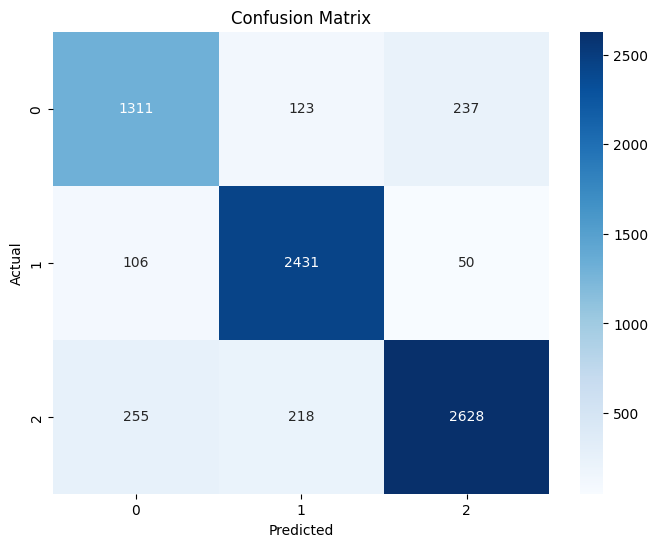

In [180]:
ngrams=(1,3)
feats = 10000

vectorizer=TfidfVectorizer(ngram_range=ngrams,max_features=feats)
    
trainx,testx,trainy,testy=train_test_split(df["clean_comment"],df["category"],test_size=0.2,random_state=42)
trainx=vectorizer.fit_transform(trainx)
testx=vectorizer.transform(testx)




smote=SMOTE(random_state=42)
trainx,trainy = smote.fit_resample(trainx,trainy)

lgbmmodel = LGBMClassifier(objective = "multiclass",
                           num_class = 3,
                           metric = "multi_logloss",
                           is_unbalance =True,
                           class_weight = "balanced",
                           reg_alpha=0.1,
                           reg_lambda=0.1,
                           learning_rate =0.0808,
                           n_estimators = 367,
                           max_depth = 20)

linreg = LogisticRegression(max_iter =1000,
                         class_weight ="balanced",
                         solver = "lbfgs")
                         #multi_class="multinomial")

klearner=KNeighborsClassifier(n_neighbors = 5)

stackingmodel = StackingClassifier(
    estimators=[("lightgbm",lgbmmodel),("linreg",linreg)], final_estimator = klearner, cv = 5
)


stackingmodel.fit(trainx,trainy)



# Make predictions on the test set
y_pred = stackingmodel.predict(testx)

# Log metrics for each class and accuracy
accuracy = accuracy_score(testy, y_pred)

print(accuracy)

classification_rep = classification_report(testy, y_pred, output_dict=True)


# Confusion matrix plot
conf_matrix = confusion_matrix(testy, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")


# Save and log the confusion matrix plot

# Log the Random Forest model
